In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
import torchbnn as bnn
from tqdm.auto import tqdm
import pyro
import pyro.distributions as dist
from torch.distributions import constraints
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import ClippedAdam
import math




# Установка случайного сида для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"

/home/nesaulov/study/urfu/coursach/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# data

сначала я удалил все дубликаты, потом заметил что одним и тем же строкам, соответствовала разная сигма, их объединил в среднее

In [2]:
df = pd.read_csv('../data/data_clear.csv')
df

,T.K,t.h,Th,C,Cr,Co,Mo,W,Al,Ti,...,S,Si,Mn,P,Hf,Cu,Ge,Ga,Ni,"Sigma, Mpa"
0,294.260,120.0,NaN,0.10,9.0,20.0,1.0,5.5,5.50,NaN,...,NaN,0.01,NaN,NaN,0.20,NaN,NaN,NaN,51.030,1186.587680
1,773.150,100.0,0.0,0.00,5.0,0.0,2.0,5.0,5.50,1.0,...,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,69.500,880.000000
2,773.150,1000.0,0.0,0.00,10.0,5.0,1.5,7.0,5.00,1.4,...,0.0,0.00,0.0,0.0,0.10,0.0,0.0,0.0,62.000,154.000000
3,823.150,100.0,0.0,0.15,9.0,10.0,0.0,10.0,5.50,1.5,...,0.0,0.00,0.0,0.0,1.20,0.0,0.0,0.0,58.085,880.000000
4,866.480,4.0,0.0,NaN,19.0,0.0,3.0,NaN,0.50,0.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,53.000,1151.424419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1044,1473.150,65.0,NaN,NaN,4.2,8.0,1.0,4.0,5.40,1.0,...,NaN,0.10,NaN,NaN,0.25,NaN,NaN,NaN,62.650,80.000000
1045,1473.150,100.0,0.0,0.06,16.0,5.0,3.0,0.0,3.50,3.5,...,0.0,0.00,0.0,0.0,1.00,0.0,0.0,0.0,62.910,57.678889
1046,1473.150,500.0,0.0,0.03,2.0,16.5,2.0,6.0,5.55,0.0,...,0.0,0.00,0.0,0.0,0.15,0.0,0.0,0.0,48.570,28.337500
1047,1560.928,90.0,NaN,NaN,10.0,5.0,NaN,4.0,5.00,1.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62.500,248.211252


In [3]:
mass = '232,03806	12,011	51,9961	58,933194	95,95	183,84	26,9815385	47,867	92,90637	10,81	55,845	88,90584	91,224	180,94788	186,207	101,07	50,9415	140,116	138,90547	32,06	28,085	54,938044	24,305	30,973761998	178,49	107,8682	63,546	208,9804	207,2	192,22	72,63	69,723	58,6934'.replace(',', '.').split()
element = 'Th	C	Cr	Co	Mo	W	Al	Ti	Nb	B	Fe	Y	Zr	Ta	Re	Ru	V	Ce	La	S	Si	Mn	Mg	P	Hf	Ag	Cu	Bi	Pb	Ir	Ge	Ga	Ni'.split()
atom_mass = dict(zip(element, mass))

In [4]:
atom_mass['Ni']

'58.6934'

In [5]:
for elem in df.drop(columns=['Sigma, Mpa', 'T.K', 't.h']).columns.to_list():
    df[elem] = df[elem] / float(atom_mass[elem])
df['sum'] = df[df.drop(columns=['Sigma, Mpa', 'T.K', 't.h']).columns.to_list()].sum(axis=1, skipna=True)
df['PLM'] = df['T.K'] * (20 + np.log10(df['t.h'])) * 1e-5

cols = df.drop(columns=['Sigma, Mpa', 'T.K', 't.h']).columns
df.loc[:, cols] = df.loc[:, cols].div(df['sum'], axis=0)
df.loc[:, cols] = df.loc[:, cols].div(df['Ni'], axis=0)



df = df.fillna(0)

df = df.drop(columns=['T.K', 't.h', 'Ni', 'sum'])

df

,Th,C,Cr,Co,Mo,W,Al,Ti,Nb,B,...,S,Si,Mn,P,Hf,Cu,Ge,Ga,"Sigma, Mpa",PLM
0,0.0,0.009576,0.199084,0.390332,0.011987,0.034410,0.234455,0.000000,0.000000,0.001064,...,0.0,0.000410,0.0,0.0,0.001289,0.0,0.0,0.0,1186.587680,0.074727
1,0.0,0.000000,0.081209,0.000000,0.017603,0.022969,0.172147,0.017643,0.000000,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,880.000000,0.143645
2,0.0,0.000000,0.182065,0.080317,0.014799,0.036046,0.175429,0.027688,0.000000,0.000000,...,0.0,0.000000,0.0,0.0,0.000530,0.0,0.0,0.0,154.000000,0.168341
3,0.0,0.012619,0.174903,0.171461,0.000000,0.054965,0.205978,0.031665,0.000000,0.001402,...,0.0,0.000000,0.0,0.0,0.006793,0.0,0.0,0.0,880.000000,0.182990
4,0.0,0.000000,0.404666,0.000000,0.034625,0.000000,0.020522,0.020822,0.060791,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,1151.424419,0.197689
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1044,0.0,0.000000,0.075674,0.127174,0.009764,0.020384,0.187497,0.019572,0.000000,0.000000,...,0.0,0.003336,0.0,0.0,0.001312,0.0,0.0,0.0,80.000000,0.301043
1045,0.0,0.004661,0.287090,0.079155,0.029171,0.000000,0.121024,0.068218,0.000000,0.001295,...,0.0,0.000000,0.0,0.0,0.005227,0.0,0.0,0.0,57.678889,0.302370
1046,0.0,0.003018,0.046482,0.338334,0.025189,0.039440,0.248569,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.0,0.001016,0.0,0.0,0.0,28.337500,0.404086
1047,0.0,0.000000,0.180609,0.079674,0.000000,0.020433,0.174025,0.029428,0.000000,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,248.211252,0.321818


In [6]:

def log_transform_target(sigma):
    sigma = np.asarray(sigma, dtype=np.float64)
    return -np.log10(sigma)

def inverse_log_transform(y):
    y = np.asarray(y, dtype=np.float64)
    return 10.0 ** (-y)

def calculate_mse(y_pred, y_true):
    """Вычисление MSE (Mean Squared Error)"""
    return torch.mean((y_pred - y_true) ** 2).item()

def calculate_rmse_absolute(sigma_pred, sigma_real):
    """
    Вычисление RMSE для физических значений σ (MPa)
    Корень из среднего квадрата абсолютных ошибок
    """
    mse = torch.mean((sigma_pred - sigma_real) ** 2).item()
    return np.sqrt(mse)

def calculate_rmse_relative(sigma_pred, sigma_real):
    """
    Вычисление RMSE согласно формуле (6) из статьи.
    Это относительная ошибка (Root Mean Square Relative Error)
    """
    epsilon = 1e-8
    relative_error = (sigma_pred - sigma_real) / (sigma_real.abs() + epsilon)
    mse_relative = torch.mean(relative_error ** 2).item()
    return np.sqrt(mse_relative)

def calculate_metrics_np(pred, real):
    eps = 1e-8
    # Абсолютная RMSE
    rmse_abs = np.sqrt(np.mean((pred - real) ** 2))
    
    # Относительная RMSE (Формула 6 из статьи)
    rel_err = (pred - real) / (real + eps)
    rmse_rel = np.sqrt(np.mean(rel_err ** 2))
    
    # MAPE
    mape = np.mean(np.abs(rel_err)) * 100
    
    # R²
    ss_res = np.sum((real - pred) ** 2)
    ss_tot = np.sum((real - np.mean(real)) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
    
    return rmse_abs, rmse_rel, mape, r2


# NN

In [7]:
class MLPRegressorNet(nn.Module):
    """
    Обычная MLP-сеть для регрессии.
    Байесовская регуляризация будет добавлена отдельно в Pyro-модели.
    """

    def __init__(
        self,
        input_dim: int,
        hidden_dim=30,
        output_dim: int = 1,
        activation: str = "tanh"
    ):
        super().__init__()

        if activation == "tanh":
            act_cls = nn.Tanh()
        elif activation == "relu":
            act_cls = nn.ReLU()
        elif activation == "silu":
            act_cls = nn.SiLU()
        elif activation == "gelu":
            act_cls = nn.GELU()
        elif activation == "elu":
            act_cls = nn.ELU()
        else:
            raise ValueError(f"Unknown activation: {activation}")


        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            act_cls,
            nn.Linear(hidden_dim, output_dim),
        )

        self.reset_parameters()

    def reset_parameters(self):
        """
        Аккуратная инициализация весов.
        Для tanh обычно хорошо работает Xavier.
        """
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_normal_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, x):
        return self.net(x).squeeze(-1)


# pyro

In [8]:
def make_map_brann_pyro_model(
    net: nn.Module,
    alpha_init: float = 0.1,
    beta_init: float = 20.0,
    alpha_prior_shape: float = 1.0,
    alpha_prior_rate: float = 10.0,
    beta_prior_shape: float = 2.0,
    beta_prior_rate: float = 0.1,
    regularize_bias: bool = True,
):
    """
    Возвращает Pyro model для MAP-BRANN.
    net:torch.nn.Module, например MLPRegressorNet.
    alpha: precision весов. Чем больше alpha, тем сильнее регуляризация.
    beta: precision шума. Чем больше beta, тем меньше шум.
    """

    def model(X, y=None):
        # Регистрируем torch.nn.Module внутри Pyro
        pyro.module("net", net)

        device = X.device
        dtype = X.dtype

        zero = torch.tensor(0.0, device=device, dtype=dtype)

        # alpha — precision весов
        alpha = pyro.param(
            "alpha",
            torch.tensor(alpha_init, device=device, dtype=dtype),
            constraint=constraints.positive
        )

        # beta — precision шума наблюдений
        beta = pyro.param(
            "beta",
            torch.tensor(beta_init, device=device, dtype=dtype),
            constraint=constraints.positive
        )

        sigma_w = torch.rsqrt(alpha)
        sigma_y = torch.rsqrt(beta)

        # Предсказание сети
        mu = net(X)

        pyro.deterministic("mu", mu)

        # Prior на веса:
        # w ~ Normal(0, alpha^{-1})
        # weight_log_prior = zero

        # for param in net.parameters():
        #     weight_log_prior = weight_log_prior + dist.Normal(
        #         zero,
        #         sigma_w
        #     ).log_prob(param).sum()

        # pyro.factor("weight_prior", weight_log_prior)

        param_log_prior = zero

        for name, param in net.named_parameters():
            is_weight = "weight" in name
            is_bias = "bias" in name

            if is_weight or (regularize_bias and is_bias):
                param_log_prior = param_log_prior + dist.Normal(
                    zero,
                    sigma_w
                ).log_prob(param).sum()

        pyro.factor("param_prior", param_log_prior)

        # Prior на alpha
        alpha_prior = dist.Gamma(
            torch.tensor(alpha_prior_shape, device=device, dtype=dtype),
            torch.tensor(alpha_prior_rate, device=device, dtype=dtype),
        )

        pyro.factor(
            "alpha_prior",
            alpha_prior.log_prob(alpha)
        )

        # Prior на beta
        beta_prior = dist.Gamma(
            torch.tensor(beta_prior_shape, device=device, dtype=dtype),
            torch.tensor(beta_prior_rate, device=device, dtype=dtype),
        )

        pyro.factor(
            "beta_prior",
            beta_prior.log_prob(beta)
        )

        # Likelihood
        with pyro.plate("data", X.shape[0]):
            pyro.sample("obs", dist.Normal(mu, sigma_y), obs=y)

    return model

def empty_guide(X, y=None):
    """
    MAP-оценка: скрытых случайных переменных в guide нет.
    Все веса, alpha и beta оптимизируются как параметры.
    """
    pass

# train

In [9]:
def to_tensor(x, device="cpu"):
    if isinstance(x, torch.Tensor):
        return x.float().to(device)
    return torch.tensor(x, dtype=torch.float32, device=device)


def train_map_brann(
    net,
    X_train,
    y_train,
    num_steps: int,
    lr: float,
    alpha_init: float,
    beta_init: float,
    alpha_prior_shape: float,
    alpha_prior_rate: float,
    beta_prior_shape: float,
    beta_prior_rate: float,
    regularize_bias: bool = True,
    clip_norm: float = 10.0,
    device: str = "cpu",
    seed: int | None = None,
):
    if seed is not None:
        pyro.set_rng_seed(seed)
        torch.manual_seed(seed)

    pyro.clear_param_store()

    X_train = to_tensor(X_train, device)
    y_train = to_tensor(y_train, device).squeeze(-1)

    net.to(device)

    model = make_map_brann_pyro_model(
        net=net,
        alpha_init=alpha_init,
        beta_init=beta_init,
        alpha_prior_shape=alpha_prior_shape,
        alpha_prior_rate=alpha_prior_rate,
        beta_prior_shape=beta_prior_shape,
        beta_prior_rate=beta_prior_rate,
        regularize_bias=regularize_bias
    )

    optimizer = ClippedAdam({
        "lr": lr,
        "clip_norm": clip_norm,
    })

    svi = SVI(
        model=model,
        guide=empty_guide,
        optim=optimizer,
        loss=Trace_ELBO()
    )

    n = X_train.shape[0]

    for step in range(num_steps):
        loss = svi.step(X_train, y_train) / n

    return net

# predict

In [10]:
def predict_map_brann(net, X, device="cpu"):
    X = to_tensor(X, device)

    net.eval()

    with torch.no_grad():
        pred = net(X)

    return pred.detach().cpu().numpy()

In [11]:
def regression_metrics_sigma(sigma_true, sigma_pred, eps=1e-8):
    sigma_true = np.asarray(sigma_true).ravel()
    sigma_pred = np.asarray(sigma_pred).ravel()

    if not np.isfinite(sigma_true).all():
        raise ValueError("sigma_true contains nan/inf")

    if not np.isfinite(sigma_pred).all():
        raise ValueError("sigma_pred contains nan/inf")

    denom = np.maximum(np.abs(sigma_true), eps)

    rmse_abs = np.sqrt(np.mean((sigma_pred - sigma_true) ** 2))
    mae_abs = np.mean(np.abs(sigma_pred - sigma_true))

    rmse_rel = np.sqrt(
        np.mean(((sigma_pred - sigma_true) / denom) ** 2)
    )

    mape = np.mean(
        np.abs((sigma_pred - sigma_true) / denom)
    ) * 100

    ss_res = np.sum((sigma_true - sigma_pred) ** 2)
    ss_tot = np.sum((sigma_true - np.mean(sigma_true)) ** 2)

    if ss_tot < eps:
        r2 = np.nan
    else:
        r2 = 1.0 - ss_res / ss_tot

    return {
        "rmse_abs": rmse_abs,
        "mae_abs": mae_abs,
        "rmse_rel": rmse_rel,
        "mape": mape,
        "r2": r2,
    }



def get_alpha_beta():
    return {
        "alpha": pyro.param("alpha").item(),
        "beta": pyro.param("beta").item(),
        "sigma_noise_scaled": 1.0 / math.sqrt(pyro.param("beta").item())
    }

In [12]:
def get_map_brann_params():
    """
    Возвращает alpha, beta и sigma_noise в нормированной шкале y.
    """

    alpha = pyro.param("alpha").item()
    beta = pyro.param("beta").item()

    sigma_noise = 1.0 / math.sqrt(beta)

    return {
        "alpha": alpha,
        "beta": beta,
        "sigma_noise_scaled": sigma_noise,
    }


In [13]:
def get_noise_std_original_scale(y_scaler):
    """
    y_scaler — твой StandardScaler для target.
    """
    beta = pyro.param("beta").item()
    sigma_noise_scaled = 1.0 / math.sqrt(beta)

    sigma_noise_original = sigma_noise_scaled * y_scaler.scale_[0]

    return sigma_noise_original


# main

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

target_col = 'Sigma, Mpa'
sigma = np.asarray(df[target_col], dtype=np.float32).reshape(-1, 1)
y = np.asarray(log_transform_target(sigma), dtype=np.float32).reshape(-1, 1).astype("float32")
X = df.copy().drop(columns=[target_col]).to_numpy().astype("float32")
print(X, y, sigma)

X_temp, X_test, y_temp, y_test, sigma_temp, sigma_test = train_test_split(
    X,
    y,
    sigma,
    test_size=0.1,
    random_state=42,
    shuffle=True
)


scaler_X = RobustScaler()
scaler_y = RobustScaler()


X_scaled = scaler_X.fit_transform(X_temp).astype("float32") # ???
y_scaled = scaler_y.fit_transform(y_temp).astype("float32").reshape(-1,1)



X_test_scaled = scaler_X.transform(X_test).astype("float32")
y_test_scaled = scaler_y.transform(y_test).astype("float32").reshape(-1,1)

# X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_scaled, test_size=0.25, random_state=42)



[[0.         0.00957601 0.19908358 ... 0.         0.         0.07472706]
 [0.         0.         0.08120891 ... 0.         0.         0.14364512]
 [0.         0.         0.18206514 ... 0.         0.         0.16834071]
 ...
 [0.         0.00301831 0.04648153 ... 0.         0.         0.40408644]
 [0.         0.         0.18060862 ... 0.         0.         0.32181817]
 [0.         0.         0.1672302  ... 0.         0.         0.2953605 ]] [[-3.0742998]
 [-2.9444826]
 [-2.1875207]
 ...
 [-1.4523616]
 [-2.3948214]
 [-2.3948214]] [[1186.5876 ]
 [ 880.     ]
 [ 154.     ]
 ...
 [  28.3375 ]
 [ 248.21126]
 [ 248.21126]]


In [15]:
X_train_opt, X_val_opt, y_train_opt, y_val_opt, sigma_train_opt, sigma_val_opt = train_test_split(
    X_scaled,
    y_scaled,
    sigma_temp,
    test_size=0.2,
    random_state=42
)

In [16]:
input_dim = X_scaled.shape[1]


net = MLPRegressorNet(
    input_dim=input_dim,
    hidden_dim=10,
    output_dim=1,
    activation="tanh"
)

history = train_map_brann(
    net=net,
    X_train=X_scaled,
    y_train=y_scaled,
    num_steps=5001,
    lr=0.01,
    alpha_init=0.1,
    beta_init=20.0,
    alpha_prior_shape = 2.0,
    alpha_prior_rate = 1.0,
    beta_prior_shape = 2.0,
    beta_prior_rate = 0.1,
)

In [17]:
y_pred_scaled = predict_map_brann(
    net=net,
    X=X_test_scaled,
)

y_pred = scaler_y.inverse_transform(
    y_pred_scaled.reshape(-1, 1)
).ravel()


In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


y_test_original = y_test.ravel()

params = get_map_brann_params()

print(params)

sigma_pred = inverse_log_transform(y_pred)


mse = mean_squared_error(y_test_original, y_pred)


rrmse = calculate_rmse_relative(torch.FloatTensor(sigma_pred), torch.FloatTensor(sigma_test))
r2 = r2_score(y_test_original, y_pred)

print(f"MSE: {mse:.4f}")
print(f"RRMSE : {rrmse:.4f}")
print(f"R2  : {r2:.4f}")


{'alpha': 10.887711524963379, 'beta': 41.81822967529297, 'sigma_noise_scaled': 0.1546383397220292}
MSE: 0.0149
RRMSE : 2.1359
R2  : 0.8432


In [19]:
rmse_absolute = calculate_rmse_absolute(torch.FloatTensor(sigma_pred), torch.FloatTensor(sigma_test))
rmse_relative = calculate_rmse_relative(torch.FloatTensor(sigma_pred), torch.FloatTensor(sigma_test))

# MAPE (Mean Absolute Percentage Error)
# mape = torch.mean(torch.abs((torch.FloatTensor(sigma_pred) - torch.FloatTensor(sigma_test)) / 
                                # (torch.FloatTensor(sigma_test) + 1e-8))) * 100


# print(f"""{y_pred_scaled[:5]=},\n {y_pred[:5]=},\n
# {sigma_pred[:5]=}, \n{sigma_real_tensor[:5]=} \n{y_test_t[:5]=}\n""")
print(f"\nРезультаты:")
print(f"  RMSE (абсолютная): {rmse_absolute:.2f} MPa")
print(f"  RRMSE (относительная, формула 6): {rmse_relative:.4f}")
# print(f"  MAPE: {mape.item():.2f}%")
print(f"  Мин. предсказанное σ: {sigma_pred.min():.2f} MPa")
print(f"  Макс. предсказанное σ: {sigma_pred.max():.2f} MPa")
print(f"  Мин. реальный σ: {sigma_test.min():.2f} MPa")
print(f"  Макс. реальный σ: {sigma_test.max():.2f} MPa")


Результаты:
  RMSE (абсолютная): 370.80 MPa
  RRMSE (относительная, формула 6): 2.1359
  Мин. предсказанное σ: 49.33 MPa
  Макс. предсказанное σ: 1654.34 MPa
  Мин. реальный σ: 57.68 MPa
  Макс. реальный σ: 1337.58 MPa


In [20]:
# print(y_pred_scaled.min(), y_pred_scaled.max())
# print(y_pred.min(), y_pred.max())
# print(y_test.min(), y_test.max())


In [21]:
# import seaborn as sns
# import matplotlib.pyplot as plt


# sns.histplot(y_pred, kde=True, bins=30, color='steelblue', stat='density')
# plt.title('Распределение переменной')
# plt.xlabel('Значение')
# plt.ylabel('Плотность')
# plt.grid(True, alpha=0.3)
# plt.show()

In [22]:
# eps = 100.0  # например, 50 MPa

# relative_rmse_safe = np.sqrt(
#     np.mean(((sigma_pred - sigma_test) / np.maximum(sigma_test, eps)) ** 2)
# )

# mape_safe = np.mean(
#     np.abs((sigma_pred - sigma_test) / np.maximum(sigma_test, eps))
# ) * 100

# print(f"Safe relative RMSE: {relative_rmse_safe:.4f}")
# print(f"Safe MAPE         : {mape_safe:.2f}%")

# graphic

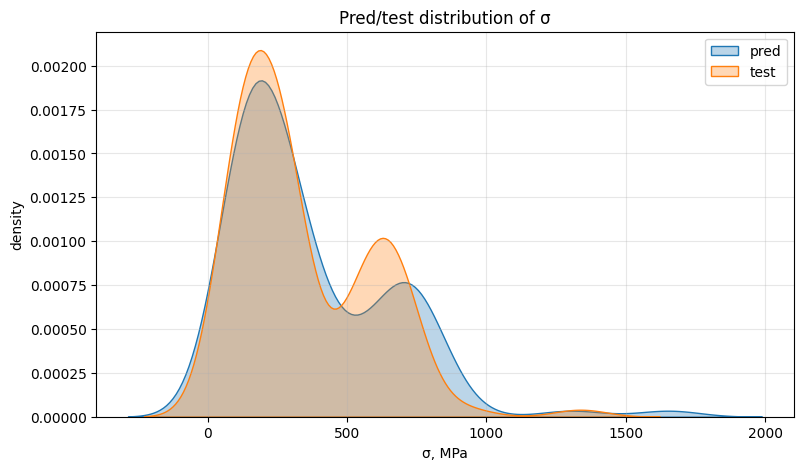

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))

# sns.kdeplot(inverse_log_transform(scaler_y.inverse_transform(y_train_opt.reshape(-1, 1))).ravel(), label="train", fill=True, alpha=0.3)
# sns.kdeplot(inverse_log_transform(scaler_y.inverse_transform(y_val_opt.reshape(-1, 1))), label="val", fill=True, alpha=0.3)
# sns.kdeplot(inverse_log_transform(y_test).ravel(), label="test", fill=True, alpha=0.3)
sns.kdeplot(sigma_pred.ravel(), label="pred", fill=True, alpha=0.3)
sns.kdeplot(sigma_test.ravel(), label="test", fill=True, alpha=0.3)



plt.xlabel("σ, MPa")
plt.ylabel("density")
plt.title("Pred/test distribution of σ")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [24]:
import numpy as np

sigma_pred = sigma_pred.ravel()
sigma_test = sigma_test.ravel()

rmse_original = np.sqrt(np.mean((sigma_pred - sigma_test) ** 2))

rmse_sorted = np.sqrt(
    np.mean((np.sort(sigma_pred) - np.sort(sigma_test)) ** 2)
)

print("RMSE original:", rmse_original)
print("RMSE sorted:", rmse_sorted)


RMSE original: 127.51708460950192
RMSE sorted: 64.88093518782709


In [25]:
from scipy.stats import pearsonr, spearmanr

print("Pearson:", pearsonr(sigma_test.ravel(), sigma_pred.ravel()))
print("Spearman:", spearmanr(sigma_test.ravel(), sigma_pred.ravel()))


Pearson: PearsonRResult(statistic=np.float64(0.8965996866809897), pvalue=np.float64(3.195127419288685e-38))
Spearman: SignificanceResult(statistic=np.float64(0.9075203696897706), pvalue=np.float64(1.3529002850761832e-40))


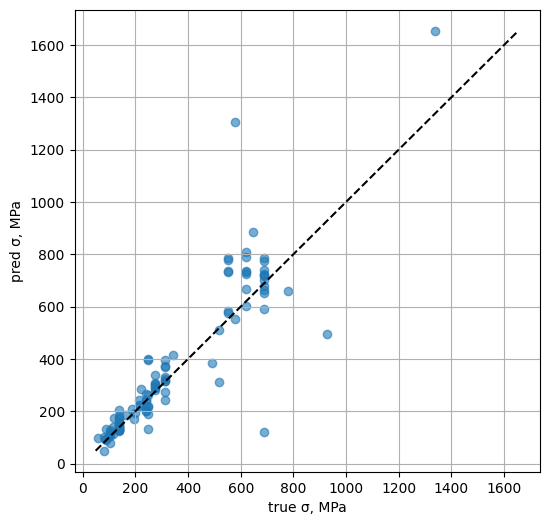

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(sigma_test, sigma_pred, alpha=0.6)
mn = min(sigma_test.min(), sigma_pred.min())
mx = max(sigma_test.max(), sigma_pred.max())
plt.plot([mn, mx], [mn, mx], "k--")
plt.xlabel("true σ, MPa")
plt.ylabel("pred σ, MPa")
plt.grid(True)
plt.show()


In [27]:
# import numpy as np
# from sklearn.model_selection import train_test_split


# bins = np.quantile(
#     sigma,
#     q=np.linspace(0, 1, 8)
# )

# # чтобы не было одинаковых границ
# bins = np.unique(bins)

# sigma_bins = np.digitize(sigma, bins[1:-1])

# X_train, X_test, sigma_train, sigma_test = train_test_split(
#     X,
#     sigma,
#     test_size=0.15,
#     random_state=42,
#     stratify=sigma_bins
# )


In [28]:
# def metrics_by_bins(sigma_true, sigma_pred):
#     bins = [
#         (0, 100),
#         (100, 300),
#         (300, 600),
#         (600, 900),
#         (900, np.inf),
#     ]

#     sigma_true = np.asarray(sigma_true).ravel()
#     sigma_pred = np.asarray(sigma_pred).ravel()

#     for low, high in bins:
#         mask = (sigma_true >= low) & (sigma_true < high)

#         if mask.sum() == 0:
#             continue

#         rmse = mean_squared_error(sigma_true[mask], sigma_pred[mask]) ** 0.5
#         mae = mean_absolute_error(sigma_true[mask], sigma_pred[mask])

#         mape_bin = np.mean(
#             np.abs((sigma_pred[mask] - sigma_true[mask]) / sigma_true[mask])
#         ) * 100

#         print(
#             f"{low:>4} - {high:<6} | "
#             f"n={mask.sum():>4} | "
#             f"RMSE={rmse:>8.2f} | "
#             f"MAE={mae:>8.2f} | "
#             f"MAPE={mape_bin:>8.2f}%"
#         )

# metrics_by_bins(sigma_test, sigma_pred)


# RF

In [29]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# обучаем на log1p(sigma)
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_scaled, y_scaled)

y_pred_scaled_rf = rf.predict(X_test_scaled)

y_pred_log_rf = scaler_y.inverse_transform(
    y_pred_scaled_rf.reshape(-1, 1)
).ravel()

mse_rf = mean_absolute_error(y_pred_log_rf, y_test)

sigma_pred_rf = inverse_log_transform(y_pred_log_rf)
sigma_pred_rf = np.clip(sigma_pred_rf, 0.0, None)

rmse_rf = mean_squared_error(sigma_test, sigma_pred_rf) ** 0.5
r2_rf = r2_score(sigma_test, sigma_pred_rf)
mape_rf = np.mean(np.abs((sigma_pred_rf - sigma_test) / sigma_test)) * 100
rrmse_fr = calculate_rmse_relative(torch.FloatTensor(sigma_pred_rf), torch.FloatTensor(sigma_test))


/home/nesaulov/study/urfu/coursach/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [30]:
print(f"RF MSE: {mse_rf:.2f} MPa")
print(f"RF RMSE: {rmse_rf:.2f} MPa")
print(f"RF R2  : {r2_rf:.4f}")
print(f"RF MAPE: {mape_rf:.2f}%")
print(f"RF RRMSE: {rrmse_fr:.2f}%")

print(f"Min pred σ: {sigma_pred_rf.min():.2f} MPa")
print(f"Max pred σ: {sigma_pred_rf.max():.2f} MPa")
print(f"Min true σ: {sigma_test.min():.2f} MPa")
print(f"Max true σ: {sigma_test.max():.2f} MPa")


RF MSE: 0.07 MPa
RF RMSE: 89.16 MPa
RF R2  : 0.8621
RF MAPE: 16.67%
RF RRMSE: 0.28%
Min pred σ: 98.71 MPa
Max pred σ: 1225.90 MPa
Min true σ: 57.68 MPa
Max true σ: 1337.58 MPa


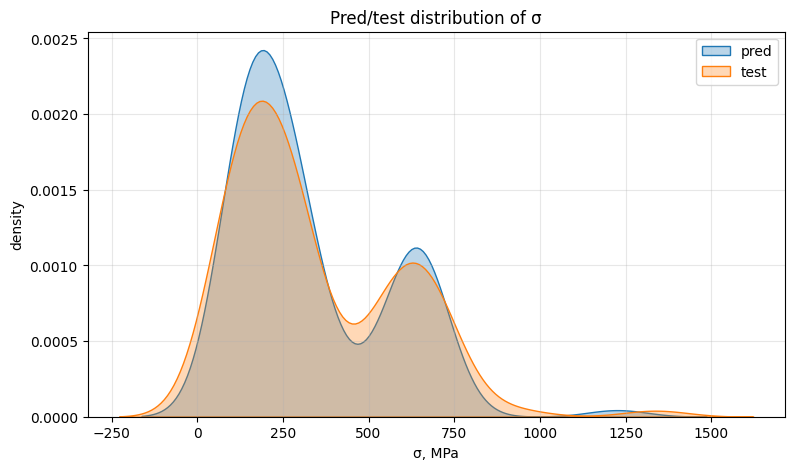

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))

sns.kdeplot(sigma_pred_rf.ravel(), label="pred", fill=True, alpha=0.3)
sns.kdeplot(sigma_test.ravel(), label="test", fill=True, alpha=0.3)



plt.xlabel("σ, MPa")
plt.ylabel("density")
plt.title("Pred/test distribution of σ")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [32]:
def metrics(y_true, y_pred):
    rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
    mae = np.mean(np.abs(y_pred - y_true))
    mape = np.mean(np.abs((y_pred - y_true) / np.maximum(np.abs(y_true), 1e-8))) * 100
    return rmse, mae, mape

rmse, mae, mape = metrics(sigma_pred, sigma_test)
print("all:", rmse, mae, mape)

abs_err = np.abs(sigma_pred - sigma_test)

for q in [0.95, 0.90, 0.85]:
    thr = np.quantile(abs_err, q)
    mask = abs_err <= thr
    rmse_q, mae_q, mape_q = metrics(sigma_test[mask], sigma_pred[mask])
    print(f"without top {100*(1-q):.0f}% errors:", rmse_q, mae_q, mape_q, "n=", mask.sum())


all: 127.51708460950192 66.51893452151124 20.182355491311984
without top 5% errors: 67.86068276343117 45.104465508855775 15.476162324898057 n= 99
without top 10% errors: 52.56534456448799 37.00159826548201 14.409792453358275 n= 94
without top 15% errors: 41.91508754316597 31.079129413565195 12.839875214370085 n= 89


In [33]:
eval_df = df.loc[pd.DataFrame(X_test).index].copy()

eval_df["sigma_test"] = sigma_test
eval_df["sigma_pred"] = sigma_pred
eval_df["err"] = eval_df["sigma_pred"] - eval_df["sigma_test"]
eval_df["abs_err"] = np.abs(eval_df["err"])
eval_df["ape"] = eval_df["abs_err"] / np.maximum(np.abs(eval_df["sigma_test"]), 1e-8) * 100

cols_to_show = [
    "sigma_test",
    "sigma_pred",
    "err",
    "abs_err",
    "ape",
]

# если есть такие колонки
extra_cols = [
    "PLM",
    "T.K",
    "t.h",
]

for col in extra_cols:
    if col in eval_df.columns:
        cols_to_show.append(col)

eval_df.sort_values("abs_err", ascending=False)[cols_to_show].head(20)


,sigma_test,sigma_pred,err,abs_err,ape,PLM
4,580.000000,1305.526221,725.526221,725.526221,125.090728,0.197689
12,689.000000,119.020716,-569.979284,569.979284,82.725585,0.177062
101,928.000000,494.789887,-433.210113,433.210113,46.682124,0.220830
64,1337.582886,1654.344768,316.761882,316.761882,23.681664,0.234163
100,645.277771,883.962865,238.685094,238.685094,36.989511,0.222271
6,551.580566,786.564011,234.983445,234.983445,42.601835,0.204396
77,551.580566,776.847546,225.266980,225.266980,40.840268,0.243126
79,517.106750,312.763548,-204.343202,204.343202,39.516638,0.197870
29,620.528137,810.425064,189.896927,189.896927,30.602468,0.199493
93,551.580566,737.775473,186.194907,186.194907,33.756611,0.218488


In [34]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

# X_train_np и X_test_np должны быть уже в той же scaled feature-шкале,
# которую ты подаёшь в модель
NN = NearestNeighbors(n_neighbors=5)
NN.fit(X_scaled)

d, idx = NN.kneighbors(X_test_scaled)

eval_df["nn_dist_1"] = d[:, 0]
eval_df["nn_idx_1"] = idx[:, 0]

bad_idx = eval_df.sort_values("abs_err", ascending=False).head(10).index

for i in bad_idx:
    print("=" * 80)
    print("TEST ROW:", i)
    print("test:", eval_df.loc[i, "sigma_test"])
    print("pred:", eval_df.loc[i, "sigma_pred"])
    print("err :", eval_df.loc[i, "err"])
    print("PLM :", eval_df.loc[i, "PLM"])

    print("\nNearest train points:")
    for k in range(5):
        j = idx[i, k]
        print(
            f"k={k+1}, dist={d[i,k]:.4f}, "
            f"train_sigma={y_scaled[j, 0]:.2f}"
        )


TEST ROW: 4
test: 580.0
pred: 1305.5262206033071
err : 725.5262206033071
PLM : 0.19768903834944665

Nearest train points:
k=1, dist=0.7706, train_sigma=-0.58
k=2, dist=1.0392, train_sigma=-0.58
k=3, dist=1.0430, train_sigma=-0.58
k=4, dist=1.1834, train_sigma=-0.58
k=5, dist=1.2774, train_sigma=-0.08
TEST ROW: 12
test: 689.0
pred: 119.02071601259871
err : -569.9792839874012
PLM : 0.17706203010255672

Nearest train points:
k=1, dist=2.0052, train_sigma=0.43
k=2, dist=2.1351, train_sigma=0.43
k=3, dist=2.3187, train_sigma=0.43
k=4, dist=2.3325, train_sigma=-0.17
k=5, dist=2.4100, train_sigma=0.43
TEST ROW: 101
test: 928.0
pred: 494.78988700235124
err : -433.21011299764876
PLM : 0.2208298845724361

Nearest train points:
k=1, dist=1.6249, train_sigma=0.43
k=2, dist=1.7332, train_sigma=-0.91
k=3, dist=1.8835, train_sigma=-0.48
k=4, dist=1.9583, train_sigma=0.43
k=5, dist=1.9720, train_sigma=-0.77
TEST ROW: 64
test: 1337.5829
pred: 1654.3447681924563
err : 316.7618824502688
PLM : 0.234163417

# optuna

In [35]:
import optuna
import traceback



def objective(trial):
    input_dim = X_scaled.shape[1]

    # hidden_dim = trial.suggest_int(
    #     "hidden_dim",
    #     2,
    #     30,
    #     log=True
    # )

    # activation = trial.suggest_categorical(
    #     "activation",
    #     ["tanh", "relu", "silu", "gelu", "elu"]
    # )

    lr = trial.suggest_float(
        "lr",
        1e-5,
        3e-3,  # -2 
        log=True
    )

    alpha_init = trial.suggest_float(
        "alpha_init",
        1e-4,
        1.0,
        log=True
    )

    beta_init = trial.suggest_float(
        "beta_init",
        1.0,
        20.0,
        log=True
    )

    # prior для alpha.
    # alpha_prior_rate больше -> prior меньше тянет alpha вверх,
    # то есть регуляризация в среднем слабее.
    alpha_prior_rate = trial.suggest_float(
        "alpha_prior_rate",
        0.1,
        1.0,
        log=True
    )

    # prior для beta.
    # beta — precision шума.
    # Большая beta = меньше шум.
    beta_prior_rate = trial.suggest_float(
        "beta_prior_rate",
        0.01,
        10.0,
        log=True
    )

    # Можно также перебирать "силу" prior на beta через shape.
    beta_prior_shape = trial.suggest_float(
        "beta_prior_shape",
        0.5,
        10.0,
        log=True
    )

    regularize_bias = trial.suggest_categorical(
    "regularize_bias",
    [True, False]
)

    net = MLPRegressorNet(
        input_dim=input_dim,
        hidden_dim=10,
        activation='tanh'
    )

    try:
        train_map_brann(
            net=net,
            X_train=X_train_opt,
            y_train=y_train_opt,
            num_steps=10000,
            lr=lr,
            alpha_init=alpha_init,
            beta_init=beta_init,
            alpha_prior_shape=1.0,
            alpha_prior_rate=alpha_prior_rate,
            beta_prior_shape=beta_prior_shape,
            beta_prior_rate=beta_prior_rate,
            regularize_bias=regularize_bias,
            clip_norm=10.0,
            device="cpu",
            seed=42,
        )

        y_pred_val_scaled = predict_map_brann(
            net,
            X_val_opt,
            device="cpu"
        )

        y_pred_val = scaler_y.inverse_transform(y_pred_val_scaled.reshape(-1, 1)).ravel()

        sigma_pred_val = inverse_log_transform(y_pred_val)

        sigma_true_val = sigma_val_opt.ravel()

        metrics = regression_metrics_sigma(
            sigma_true_val,
            sigma_pred_val
        )

        params = get_alpha_beta()

        trial.set_user_attr("rmse_abs", metrics["rmse_abs"])
        trial.set_user_attr("mae_abs", metrics["mae_abs"])
        trial.set_user_attr("mape", metrics["mape"])
        trial.set_user_attr("r2", metrics["r2"])
        trial.set_user_attr("final_alpha", params["alpha"])
        trial.set_user_attr("final_beta", params["beta"])
        trial.set_user_attr("sigma_noise_scaled", params["sigma_noise_scaled"])

        # Главная метрика оптимизации
        return metrics["rmse_rel"]


    except Exception as e:
        print("TRIAL FAILED")
        print(e)
        traceback.print_exc()
        return float("inf")



In [36]:
study = optuna.create_study(
    direction="minimize",
    study_name="map_brann_sigma"
)

study.optimize(
    objective,
    n_trials=50,
    show_progress_bar=True
)

print("Best value:", study.best_value)
print("Best params:")

for k, v in study.best_params.items():
    print(f"{k}: {v}")

print("Best user attrs:")
for k, v in study.best_trial.user_attrs.items():
    print(f"{k}: {v}")


[I 2026-06-17 14:32:15,863] A new study created in memory with name: map_brann_sigma
Best trial: 0. Best value: 0.350396:   2%|▏         | 1/50 [00:29<23:57, 29.33s/it]

[I 2026-06-17 14:32:45,196] Trial 0 finished with value: 0.3503956663670251 and parameters: {'lr': 0.00012504511880281536, 'alpha_init': 0.0026938353627068, 'beta_init': 15.71641138059921, 'alpha_prior_rate': 0.18641787606799176, 'beta_prior_rate': 0.5761035162242204, 'beta_prior_shape': 8.155968885530362, 'regularize_bias': False}. Best is trial 0 with value: 0.3503956663670251.


Best trial: 0. Best value: 0.350396:   4%|▍         | 2/50 [01:03<25:36, 32.01s/it]

[I 2026-06-17 14:33:19,088] Trial 1 finished with value: 0.6174830223463563 and parameters: {'lr': 6.317505075188089e-05, 'alpha_init': 0.005291975508467377, 'beta_init': 17.23162600603601, 'alpha_prior_rate': 0.5913267104411107, 'beta_prior_rate': 8.034991632401097, 'beta_prior_shape': 4.770703584969806, 'regularize_bias': True}. Best is trial 0 with value: 0.3503956663670251.


Best trial: 0. Best value: 0.350396:   6%|▌         | 3/50 [01:31<23:54, 30.51s/it]

...

Best trial: 0. Best value: 0.350396:  18%|█▊        | 9/50 [04:43<22:02, 32.25s/it]

[I 2026-06-17 14:36:59,367] Trial 8 finished with value: 0.6918317014399045 and parameters: {'lr': 0.00014062109810142302, 'alpha_init': 0.00016076618361706173, 'beta_init': 6.322096803299015, 'alpha_prior_rate': 0.1364941386895476, 'beta_prior_rate': 1.5524747410150082, 'beta_prior_shape': 9.299957831009765, 'regularize_bias': True}. Best is trial 0 with value: 0.3503956663670251.


Best trial: 0. Best value: 0.350396:  18%|█▊        | 9/50 [04:46<21:43, 31.79s/it]


[W 2026-06-17 14:37:01,976] Trial 9 failed with parameters: {'lr': 0.0007191965972144244, 'alpha_init': 0.0005900683845183872, 'beta_init': 5.7373658388274515, 'alpha_prior_rate': 0.28554182528183325, 'beta_prior_rate': 3.8181289962299934, 'beta_prior_shape': 1.3303422690213547, 'regularize_bias': False} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/nesaulov/study/urfu/coursach/.venv/lib/python3.12/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_1396058/235571624.py", line 82, in objective
    train_map_brann(
  File "/tmp/ipykernel_1396058/280465839.py", line 61, in train_map_brann
    loss = svi.step(X_train, y_train) / n
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/nesaulov/study/urfu/coursach/.venv/lib/python3.12/site-packages/pyro/infer/svi.py", line 145, in step
    loss = self.loss_and_grads(self.model, self.g

KeyboardInterrupt: 

Best value: 0.854725547408852
Best params:
hidden_dim: 11
activation: gelu
lr: 0.026053779483632567
alpha_init: 0.0009531055978600405
beta_init: 1.1781615420752112
alpha_prior_rate: 2.9549589377332244
beta_prior_rate: 0.03822059220992772
beta_prior_shape: 0.5580949970329177
Best user attrs:
rmse_abs: 145.0190057574377
mae_abs: 99.6212582665093
mape: 40.53959317888554
r2: 0.6664255188259909
final_alpha: 13.614280700683594
final_beta: 7.910255432128906
sigma_noise_scaled: 0.3555533264955847

# best model

In [ ]:
best_params = study.best_params


best_net = MLPRegressorNet(
    input_dim=X_scaled.shape[1],
    hidden_dim=10,
    activation="tanh"
)

train_map_brann(
    net=best_net,
    X_train=X_train_opt,
    y_train=y_train_opt,
    num_steps=15000,
    lr=best_params["lr"],
    alpha_init=best_params["alpha_init"],
    beta_init=best_params["beta_init"],
    alpha_prior_shape=1.0,
    alpha_prior_rate=best_params["alpha_prior_rate"],
    beta_prior_shape=best_params["beta_prior_shape"],
    beta_prior_rate=best_params["beta_prior_rate"],
    regularize_bias=best_params["regularize_bias"],
    clip_norm=10.0,
    device="cpu",
    seed=42,
)


MLPRegressorNet(
  (net): Sequential(
    (0): Linear(in_features=27, out_features=10, bias=True)
    (1): Tanh()
    (2): Linear(in_features=10, out_features=1, bias=True)
  )
)

In [ ]:
y_pred_val_scaled = predict_map_brann(
    best_net,
    X_val_opt,
    device="cpu"
)

y_pred_val = scaler_y.inverse_transform(y_pred_val_scaled.reshape(-1, 1)).ravel()

sigma_pred_val = inverse_log_transform(y_pred_val)

sigma_true_val = sigma_val_opt.ravel()

metrics = regression_metrics_sigma(
    sigma_true_val,
    sigma_pred_val
)

print("Final validation metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

print("Alpha/beta:")
print(get_alpha_beta())

print(f"Min pred σ: {sigma_pred_val.min():.2f} MPa")
print(f"Max pred σ: {sigma_pred_val.max():.2f} MPa")
print(f"Min true σ: {sigma_true_val.min():.2f} MPa")
print(f"Max true σ: {sigma_true_val.max():.2f} MPa")


Final validation metrics:
rmse_abs: 118.5561
mae_abs: 60.0557
rmse_rel: 0.3767
mape: 18.7476
r2: 0.7994
Alpha/beta:
{'alpha': 11.436789512634277, 'beta': 51.1609992980957, 'sigma_noise_scaled': 0.139807506695711}
Min pred σ: 45.68 MPa
Max pred σ: 1708.45 MPa
Min true σ: 28.34 MPa
Max true σ: 1241.06 MPa


In [ ]:
y_pred_test_scaled = predict_map_brann(
    best_net,
    X_test,
    device="cpu"
)

y_pred_test = scaler_y.inverse_transform(y_pred_test_scaled.reshape(-1, 1)).ravel()

sigma_pred_test = inverse_log_transform(y_pred_test)

sigma_true_test = sigma_test.ravel()

metrics = regression_metrics_sigma(
    sigma_true_test,
    sigma_pred_test
)

print("Final validation metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

print("Alpha/beta:")
print(get_alpha_beta())

print(f"Min pred σ: {sigma_pred_val.min():.2f} MPa")
print(f"Max pred σ: {sigma_pred_val.max():.2f} MPa")
print(f"Min true σ: {sigma_true_val.min():.2f} MPa")
print(f"Max true σ: {sigma_true_val.max():.2f} MPa")

Final validation metrics:
rmse_abs: 238.2113
mae_abs: 169.2096
rmse_rel: 0.6431
mape: 51.7068
r2: 0.0154
Alpha/beta:
{'alpha': 11.436789512634277, 'beta': 51.1609992980957, 'sigma_noise_scaled': 0.139807506695711}
Min pred σ: 45.68 MPa
Max pred σ: 1708.45 MPa
Min true σ: 28.34 MPa
Max true σ: 1241.06 MPa
